=== Convergence Study ===
  Gaussian c=0.5, N=1000: |λ_sub|=0.970686 (0.2s)


  Gaussian c=0.5, N=2000: |λ_sub|=0.960059 (0.1s)


  Gaussian c=0.5, N=4000: |λ_sub|=0.968750 (0.3s)


  Gaussian c=0.5, N=8000: |λ_sub|=0.966285 (0.7s)


  Gaussian c=0.5, N=16000: |λ_sub|=0.966392 (3.8s)
  Gaussian c=1.0, N=1000: |λ_sub|=0.962682 (0.2s)


...

  Gaussian c=4.0, N=16000: |λ_sub|=0.967924 (2.1s)
  Ulam N=1000: |λ_sub|=1.000000 (0.0s)
  Ulam N=2000: |λ_sub|=1.000000 (0.0s)


  Ulam N=4000: |λ_sub|=1.000000 (0.1s)


  Ulam N=8000: |λ_sub|=1.000000 (0.5s)


  Ulam N=16000: |λ_sub|=1.000000 (2.5s)
Computing trajectory survival...


fig8 done


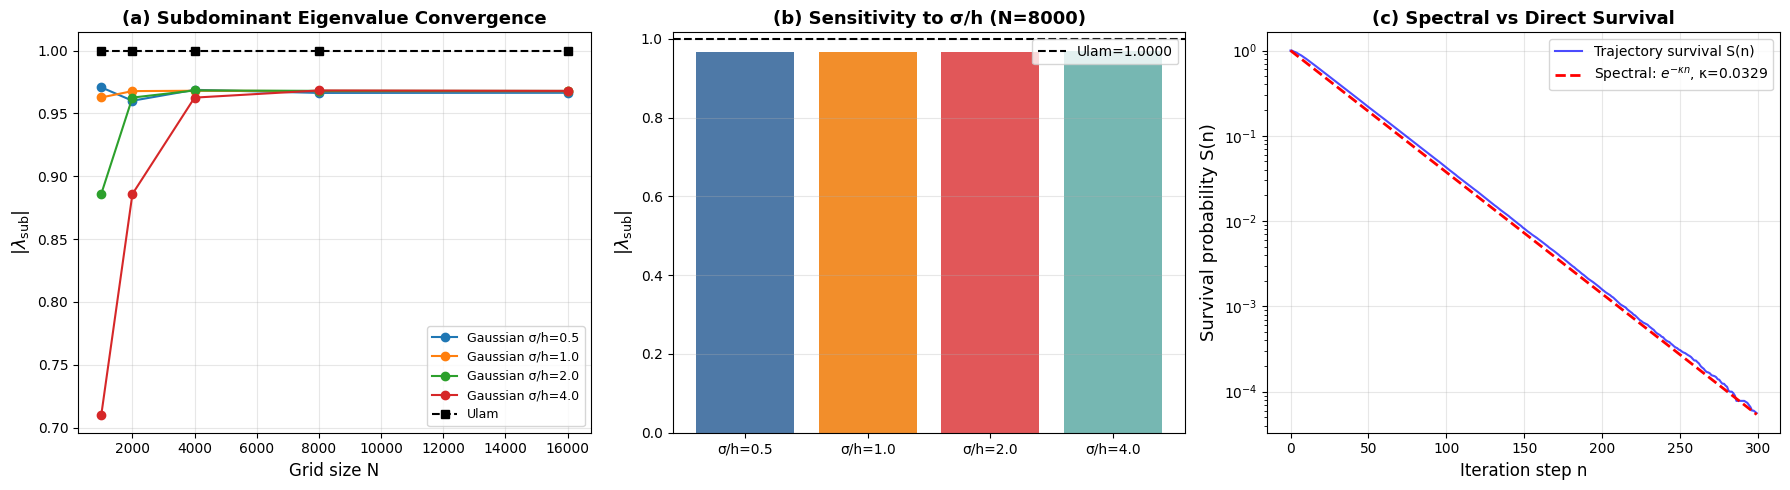

In [1]:
"""Fig 8: Transfer operator convergence study.
Vary N and sigma/h, compare Gaussian kernel vs Ulam, validate against trajectory survival."""
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
import matplotlib

import matplotlib.pyplot as plt
import time

MU = 1.7548776662466927
X_STAR = (-1.0 + np.sqrt(1.0 + 4.0 * MU)) / (2.0 * MU)
TARGETS = np.array([0.0, 1.0, 1.0 - MU])

def build_gaussian_matrix(n_bins, mu, c_ratio):
    dx = 2.0 / n_bins
    eps = c_ratio * dx
    inv_2eps2 = 1.0 / (2.0 * eps**2)
    radius = int(5.0 * eps / dx) + 1
    xs = np.linspace(-1.0 + dx*0.5, 1.0 - dx*0.5, n_bins)
    x_next = 1.0 - mu * xs * xs
    transitions = np.zeros((n_bins, n_bins), dtype=np.float64)
    for i in range(n_bins):
        xn = x_next[i]
        j_center = int((xn + 1.0) / dx)
        j_start = max(0, j_center - radius)
        j_end = min(n_bins - 1, j_center + radius)
        cj = xs[j_start:j_end+1]
        probs = np.exp(-(cj - xn)**2 * inv_2eps2)
        w_sum = np.sum(probs)
        if w_sum > 1e-18:
            transitions[i, j_start:j_end+1] = probs / w_sum
        else:
            jc = min(max(0, j_center), n_bins - 1)
            transitions[i, jc] = 1.0
    return transitions

def build_ulam_matrix(n_bins, mu):
    dx = 2.0 / n_bins
    xs = np.linspace(-1.0 + dx*0.5, 1.0 - dx*0.5, n_bins)
    x_next = 1.0 - mu * xs * xs
    transitions = np.zeros((n_bins, n_bins), dtype=np.float64)
    for i in range(n_bins):
        j = int((x_next[i] + 1.0) / dx)
        j = min(max(0, j), n_bins - 1)
        transitions[i, j] = 1.0
    return transitions

def get_lambda_sub(matrix):
    P = sp.csr_matrix(matrix)
    vals, _ = eigs(P.T, k=6, which='LM')
    mods = np.abs(vals)
    idx = np.argsort(mods)[::-1]
    mods_sorted = mods[idx]
    for m in mods_sorted[3:]:
        if m < 0.999:
            return m
    return mods_sorted[3]

def trajectory_survival_rate(mu, n_samples=500000, max_steps=300, eps_absorb=1e-3):
    x = np.random.uniform(-1, 1, n_samples)
    survival = np.zeros(max_steps)
    active = np.ones(n_samples, dtype=bool)
    for t in range(max_steps):
        survival[t] = np.sum(active)
        if not np.any(active):
            break
        d = np.min(np.abs(x[active, None] - TARGETS[None, :]), axis=1)
        converged = d < eps_absorb
        active_idx = np.where(active)[0]
        active[active_idx[converged]] = False
        x[active] = 1.0 - mu * x[active]**2
    survival = survival / n_samples
    return survival

# --- Run convergence study ---
N_values = [1000, 2000, 4000, 8000, 16000]
c_values = [0.5, 1.0, 2.0, 4.0]

print("=== Convergence Study ===")
results_gauss = {}
for c in c_values:
    results_gauss[c] = []
    for N in N_values:
        t0 = time.time()
        M = build_gaussian_matrix(N, MU, c)
        lsub = get_lambda_sub(M)
        dt = time.time() - t0
        results_gauss[c].append(lsub)
        print(f"  Gaussian c={c}, N={N}: |λ_sub|={lsub:.6f} ({dt:.1f}s)")

results_ulam = []
for N in N_values:
    t0 = time.time()
    M = build_ulam_matrix(N, MU)
    lsub = get_lambda_sub(M)
    dt = time.time() - t0
    results_ulam.append(lsub)
    print(f"  Ulam N={N}: |λ_sub|={lsub:.6f} ({dt:.1f}s)")

# Direct trajectory survival
print("Computing trajectory survival...")
surv = trajectory_survival_rate(MU)
valid = surv > 1e-6
t_range = np.arange(len(surv))[valid]
s_range = surv[valid]

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) |λ_sub| vs N for different σ/h
for c in c_values:
    axes[0].plot(N_values, results_gauss[c], 'o-', label=f'Gaussian σ/h={c}')
axes[0].plot(N_values, results_ulam, 's--', color='black', label='Ulam')
axes[0].set_xlabel('Grid size N', fontsize=12)
axes[0].set_ylabel(r'$|\lambda_{\mathrm{sub}}|$', fontsize=13)
axes[0].set_title('(a) Subdominant Eigenvalue Convergence', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# (b) σ/h sensitivity at N=8000
idx_8k = N_values.index(8000)
vals_at_8k = [results_gauss[c][idx_8k] for c in c_values]
axes[1].bar([f'σ/h={c}' for c in c_values], vals_at_8k, color=['#4E79A7','#F28E2B','#E15759','#76B7B2'])
axes[1].axhline(y=results_ulam[idx_8k], color='black', linestyle='--', label=f'Ulam={results_ulam[idx_8k]:.4f}')
axes[1].set_ylabel(r'$|\lambda_{\mathrm{sub}}|$', fontsize=13)
axes[1].set_title('(b) Sensitivity to σ/h (N=8000)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# (c) Spectral vs trajectory survival
kappa_spec = -np.log(results_gauss[1.0][-1])
axes[2].semilogy(t_range, s_range, 'b-', alpha=0.7, label='Trajectory survival S(n)')
axes[2].semilogy(t_range, np.exp(-kappa_spec * t_range), 'r--', linewidth=2,
                 label=f'Spectral: $e^{{-\\kappa n}}$, κ={kappa_spec:.4f}')
axes[2].set_xlabel('Iteration step n', fontsize=12)
axes[2].set_ylabel('Survival probability S(n)', fontsize=13)
axes[2].set_title('(c) Spectral vs Direct Survival', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig8.png', dpi=300)
print("fig8 done")
